# Baseline Models - Auto-Urgency Tagging (LEN-05)
1. **Logistic Regression** — cepat, interpretatif, sebagai acuan minimum
2. **Random Forest** — ensemble berbasis pohon, lebih robust terhadap noise

Dataset diseimbangkan menggunakan teknik **Undersampling** (High = Medium = Low) agar jumlah kelas merata sebelum pelatihan.



## Cell 1 — Setup Lingkungan & Import Library

In [1]:
import sys
import os

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    
    PROJECT_ROOT = '/content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research'
    if not os.path.exists(PROJECT_ROOT):
        PROJECT_ROOT = '/content/drive/MyDrive/lentera-ml-research'
        
    os.chdir(PROJECT_ROOT)
    print(f"Berjalan di Google Colab. Direktori aktif saat ini: {os.getcwd()}")
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    print(f"Berjalan secara lokal. Project root: {PROJECT_ROOT}")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import split_data, extract_tfidf

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Berjalan di Google Colab. Direktori aktif saat ini: /content/drive/MyDrive/lentera-ml-research



## Cell 2 — Load & Validasi Dataset Bersih

In [2]:

DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'cleaned_complaints.csv')

df = pd.read_csv(DATA_PATH)
print(f"Dataset berhasil dimuat. Shape awal: {df.shape}")
print(f"Kolom tersedia: {df.columns.tolist()}")
print()

df = df.dropna(subset=['Cleaned_Narrative', 'Urgency'])
print(f"Shape setelah dropna: {df.shape}")
print()

print("\nMelakukan Undersampling...")
min_class_size = df['Urgency'].value_counts().min()
df_high = df[df['Urgency'] == 'High']
df_medium = df[df['Urgency'] == 'Medium']
df_low = df[df['Urgency'] == 'Low']
if len(df_high) > min_class_size:
    df_high = df_high.sample(min_class_size, random_state=42)
if len(df_medium) > min_class_size:
    df_medium = df_medium.sample(min_class_size, random_state=42)
if len(df_low) > min_class_size:
    df_low = df_low.sample(min_class_size, random_state=42)
df = pd.concat([df_high, df_medium, df_low])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Distribusi kelas setelah undersampling:")
print(df['Urgency'].value_counts())


Dataset berhasil dimuat. Shape awal: (121485, 3)
Kolom tersedia: ['Raw_Filtered_Narrative', 'Cleaned_Narrative', 'Urgency']

Shape setelah dropna: (121485, 3)


Melakukan Undersampling...
Distribusi kelas setelah undersampling:
Urgency
High      19431
Medium    19431
Low       19431
Name: count, dtype: int64



## Cell 3 — Visualisasi Distribusi Kelas

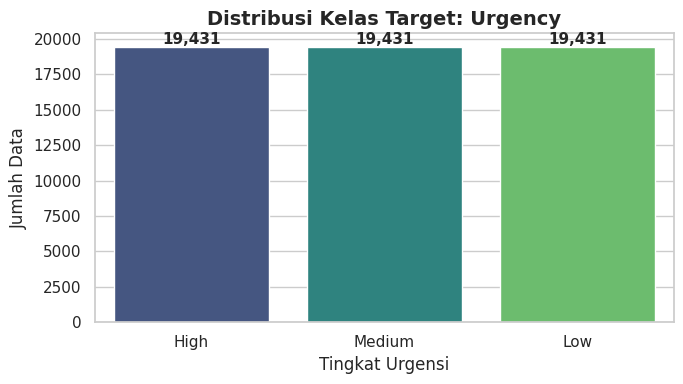

In [3]:
order = ['High', 'Medium', 'Low']
counts = df['Urgency'].value_counts().reindex(order)

plt.figure(figsize=(7, 4))
bars = sns.barplot(x=counts.index, y=counts.values, palette='viridis', hue=counts.index, legend=False)

for bar in bars.patches:
    bars.annotate(
        f'{int(bar.get_height()):,}',
        (bar.get_x() + bar.get_width() / 2., bar.get_height()),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.title('Distribusi Kelas Target: Urgency', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Urgensi')
plt.ylabel('Jumlah Data')
plt.tight_layout()
plt.show()


## Cell 4 — Data Splitting (Pipeline LEN-04)

In [4]:
df_train, df_val, df_test = split_data(
    df,
    text_col='Cleaned_Narrative',
    target_col='Urgency'
)

y_train = df_train['Urgency']
y_val   = df_val['Urgency']
y_test  = df_test['Urgency']

print("\nDistribusi kelas pada setiap split:")
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"  {name}: {y.value_counts().to_dict()}")

Train size: 40805, Val size: 8744, Test size: 8744

Distribusi kelas pada setiap split:
  Train: {'High': 13602, 'Medium': 13602, 'Low': 13601}
  Val: {'High': 2915, 'Low': 2915, 'Medium': 2914}
  Test: {'Low': 2915, 'Medium': 2915, 'High': 2914}



## Cell 5 — Ekstraksi Fitur TF-IDF (Pipeline LEN-04)

In [5]:
X_train_tfidf, X_val_tfidf, X_test_tfidf, tfidf_vectorizer = extract_tfidf(
    train_texts=df_train['Cleaned_Narrative'],
    val_texts=df_val['Cleaned_Narrative'],
    test_texts=df_test['Cleaned_Narrative']
)

print(f"Shape fitur TF-IDF:")
print(f"  X_train : {X_train_tfidf.shape}")
print(f"  X_val   : {X_val_tfidf.shape}")
print(f"  X_test  : {X_test_tfidf.shape}")
print(f"\nUkuran vocabulary TF-IDF: {len(tfidf_vectorizer.vocabulary_)} kata")

Shape fitur TF-IDF:
  X_train : (40805, 5000)
  X_val   : (8744, 5000)
  X_test  : (8744, 5000)

Ukuran vocabulary TF-IDF: 5000 kata


In [6]:
fitur_names = tfidf_vectorizer.get_feature_names_out()
print(fitur_names[2000:2050])

['federal state' 'federal state law' 'federal student'
 'federal student loan' 'federal trade' 'federal trade commission'
 'federally' 'federally protect' 'federally protect consumer' 'fee'
 'fee account' 'fee assess' 'fee charge' 'fee moneyamount' 'feel'
 'feel item' 'feel item report' 'feel like' 'fha' 'field' 'fifth' 'figure'
 'file' 'file account' 'file cfpb' 'file claim' 'file complaint'
 'file complaint consumer' 'file complaint inaccurate' 'file consumer'
 'file datemask' 'file dispute' 'file formal' 'file formal complaint'
 'file ftc' 'file ftc identity' 'file police' 'file police report'
 'file report' 'file request' 'file request pursuant' 'file right'
 'file right fair' 'filing' 'final' 'finalize' 'finally' 'finance'
 'finance charge' 'financial']



## Cell 6 — Model 1: Logistic Regression

In [8]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Melatih Logistic Regression...")
lr_model.fit(X_train_tfidf, y_train)
print("Pelatihan selesai.")

Melatih Logistic Regression...
Pelatihan selesai.



## Cell 7 — Evaluasi Logistic Regression pada Test Set

In [9]:
y_pred_lr = lr_model.predict(X_test_tfidf)

print("  EVALUASI MODEL 1: Logistic Regression (Test Set)")

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['High', 'Medium', 'Low']
))

  EVALUASI MODEL 1: Logistic Regression (Test Set)
              precision    recall  f1-score   support

        High       0.89      0.81      0.85      2914
      Medium       0.75      0.83      0.79      2915
         Low       0.78      0.77      0.77      2915

    accuracy                           0.80      8744
   macro avg       0.80      0.80      0.80      8744
weighted avg       0.80      0.80      0.80      8744




## Cell 8 — Confusion Matrix Logistic Regression

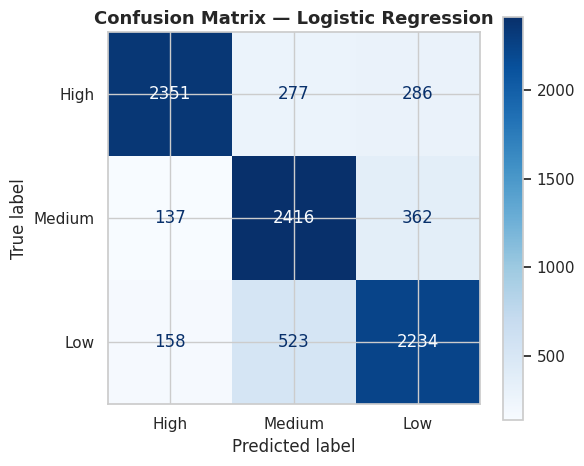

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=['High', 'Medium', 'Low'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Cell 9 — Model 2: Random Forest

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=200,

    n_jobs=-1,
    random_state=42
)

print("Melatih Random Forest (200 trees)")
rf_model.fit(X_train_tfidf, y_train)
print("Pelatihan selesai.")

Melatih Random Forest (200 trees)
Pelatihan selesai.



## Cell 10 — Evaluasi Random Forest pada Test Set

In [12]:
y_pred_rf = rf_model.predict(X_test_tfidf)

print("  EVALUASI MODEL 2: Random Forest (Test Set)")

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['High', 'Medium', 'Low']
))

  EVALUASI MODEL 2: Random Forest (Test Set)
              precision    recall  f1-score   support

        High       0.92      0.85      0.89      2914
      Medium       0.78      0.85      0.81      2915
         Low       0.80      0.79      0.80      2915

    accuracy                           0.83      8744
   macro avg       0.83      0.83      0.83      8744
weighted avg       0.83      0.83      0.83      8744




## Cell 11 — Confusion Matrix Random Forest

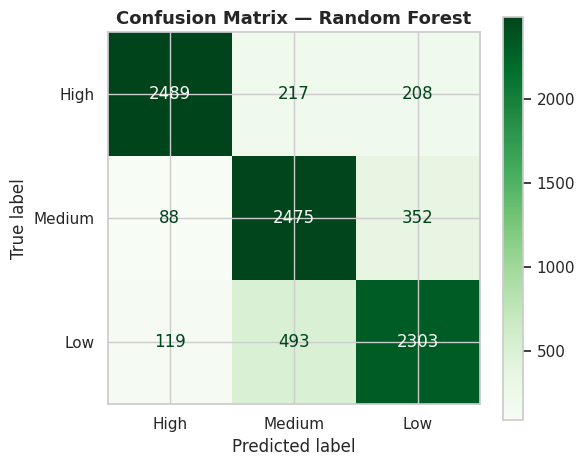

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['High', 'Medium', 'Low'],
    cmap='Greens',
    ax=ax
)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Cell 12 — Perbandingan Performa Kedua Model (Ringkasan)

In [14]:
from sklearn.metrics import f1_score, accuracy_score

results = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1-Score Macro': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ],
    'F1-Score Weighted': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted')
    ]
}

df_results = pd.DataFrame(results)

df_results[['Accuracy', 'F1-Score Macro', 'F1-Score Weighted']] = \
    df_results[['Accuracy', 'F1-Score Macro', 'F1-Score Weighted']].map(lambda x: f'{x:.4f}')

print("  RINGKASAN PERBANDINGAN PERFORMA MODEL BASELINE")
print(df_results.to_string(index=False))
print()
print("Catatan: F1-Score Macro diprioritaskan sebagai metrik utama")
print("         karena dataset memiliki ketidakseimbangan kelas.")

  RINGKASAN PERBANDINGAN PERFORMA MODEL BASELINE
              Model Accuracy F1-Score Macro F1-Score Weighted
Logistic Regression   0.8007         0.8015            0.8015
      Random Forest   0.8311         0.8320            0.8320

Catatan: F1-Score Macro diprioritaskan sebagai metrik utama
         karena dataset memiliki ketidakseimbangan kelas.



## Cell 13 — Visualisasi Perbandingan F1-Score per Kelas

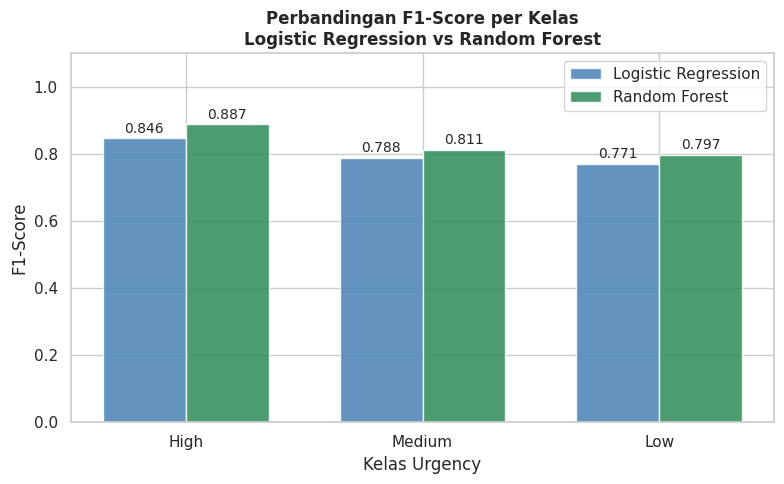

In [15]:
from sklearn.metrics import classification_report

classes = ['High', 'Medium', 'Low']

report_lr = classification_report(y_test, y_pred_lr, target_names=classes, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, target_names=classes, output_dict=True)

f1_lr = [report_lr[c]['f1-score'] for c in classes]
f1_rf = [report_rf[c]['f1-score'] for c in classes]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, f1_lr, width, label='Logistic Regression', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_rf, width, label='Random Forest', color='seagreen', alpha=0.85)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)

ax.set_xlabel('Kelas Urgency')
ax.set_ylabel('F1-Score')
ax.set_title('Perbandingan F1-Score per Kelas\nLogistic Regression vs Random Forest', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()